In [ ]:
import numpy as np
import tensortools as tt
import matplotlib.pyplot as plt
import gdown

In [ ]:
#download the LC / M1 Mouse data
url = "https://drive.google.com/file/d/1m9m6-HDDFmjfZlGbruJ1iwqZOOiuc3ZI/view?usp=drive_link"
output = "M1_LC_data.npy"
gdown.download(url, output, quiet = False)

## Tensor Decompositions for neural data analysis

In this tutorial, you will learn how to fit and analyze a particular tensor decomposition, tensor component analysis (TCA), as applied to neural data. Tensor component analysis (TCA) is one particular tensor decomposition method among many. For a systematic exploration of tensor decomposition methods, see [these excellent course notes](https://www-labs.iro.umontreal.ca/~grabus/courses/ift6760a-w19.html) or this review: [Kolda & Bader, 2009 Tensor Decompositions and Applications](https://epubs.siam.org/doi/10.1137/07070111X). In this tutorial, I will mostly be following the methods of [Williams et al., 2018](https://www.cell.com/neuron/fulltext/S0896-6273(18)30387-8), which provides a reasonably gentle introduction to TCA. 

Code is taken from the [__tensortools__](https://github.com/neurostatslab/tensortools) library, imported above, which is associated with the same paper. Neural data is taken from the [Neural Latents Benchmark](https://github.com/neurallatents/nlb_tools), hosted on the [DANDI Archive](https://about.dandiarchive.org/), which is a repository for hosting open neuroscience datasets that can be very useful for prototyping new data analysis tools.

The tutorial is broken into three parts:

__Part 1__: Applying tensor decompositions to synthetic data

__Part 2__: Implementing the Alternating Least Squares (ALS) fitting procedure for TCA

__Part 3__: Applying TCA to neural data

__Part 4__: As time allows, apply TCA to your own dataset of interest and interpret the results

The four parts are mostly independent, and if you are already familiar with TCA feel free to skip to __Part 3__.



## Background


Here, we will go over the necessary background to understand what is being done with TCA and how it relates to better known algorithms like principal component analysis (PCA). This will borrow heavily from the methods section of [Williams et al., 2018](https://www.cell.com/neuron/fulltext/S0896-6273(18)30387-8).

### Intro to Tensors

Tensors are a generalization of vectors and matrices. Basically, tensors are data arrays with multiple axes or dimesions (analogous to a numpy [ndarray](https://numpy.org/doc/2.4/reference/generated/numpy.ndarray.html)). These axes are called the *modes* of a tensor, and the dimensions are the lengths of each mode. A vector has 1 mode, an array has 2 modes, and a tensor can have an arbitrary number of modes. In this tutorial we will focus on tensors with 3 modes (typically $N$ neurons, $T$ time steps, and $K$ trials), but everything that we do here will apply to tensors with arbitrary ($M \geq 3$) modes. As with matrices, one can define a variety of different types of multiplication for tensors to extend ideas from more traditional linear algebra; for the sake of simplicity, we will be mostly sweeping this complexity under the rug, providing just enough detail to motivate you to learn more on your own time.

$\providecommand{\datatensor}{\boldsymbol{\chi}}$
$\providecommand{\datamat}{\boldsymbol{X}}$
$\providecommand{\weight}{\boldsymbol{W}}$
$\providecommand{\loadings}{\boldsymbol{B}}$

### Overview of matrix decompositions
Generally in neuroscience experiments we are provided with a data tensor $\datatensor \in \mathbb{R}^N \times \mathbb{R}^T \times \mathbb{R}^K$, where element $\datatensor_{ntk}$ provides the activity of the $n$ -th recording unit at the $t$ -th timestep on the $k$ -th trial. We typically want to use data analysis techniques to understand or visualize what our data contains, but there are too many axes along which activity varies (much of which may be noise) to readily make sense of what we are looking at.

A *matrix decomposition* first reshapes the data tensor into a matrix $\datamat \in \mathbb{R}^N \times \mathbb{R}^{TK}$ by collapsing the last two modes of the tensor into one (as one would do by reshaping a numpy ndarray). Then, the matrix decomposition seeks to replace the matrix $\datamat$ with a *simpler* matrix $\hat \datamat$ that is easier to visualize and manipulate, while still preserving important properties of the original data. PCA, for instance, takes $\hat \datamat = \weight \loadings^T$, where $\weight = \datamat \loadings$ and $\loadings$ is constrained to be an orthogonal matrix. The operation $\datamat \loadings \loadings^T$ projects the data onto the axes specified by the matrix $\loadings$; if $\loadings$ is a low rank matrix (e.g. $\loadings \in \mathbb{R}^N \times \mathbb{R}^R$) for $R << N$, then information about the original dataset is lost. PCA solves an *optimization* problem, seeking to find the *best* matrix $\loadings$ that preserves information about the original dataset, subject to the constraint that the the matrix is orthonormal. In equations, PCA optimizes:

\begin{equation}
\min_{\weight, \loadings} \| \datamat - \hat \datamat \|_2^2 = \| \datamat - \datamat \loadings \loadings^T \|_2^2 ~~~~~s.t. ~~~~~~\loadings^T \loadings = \mathbf{I}.
\end{equation}

Interestingly, this equation has a *closed form* solution, but viewing PCA as an optimization problem is more important for understanding how it relates to TCA.

### What is a tensor decomposition?
A tensor decomposition is a decomposition that operates directly on the tensor $\datatensor$, as opposed to its flattened matrix representation $\datamat$. Basically, any tensor decomposition that we will be concerned with can be formalized as minimizing the optimization problem:

\begin{equation}
\min_{\hat \datatensor} \| \datatensor - \hat \datatensor \|_F^2 \equiv \sum_{ntk} (\datatensor_{ntk} - \hat \datatensor_{ntk})^2,
\end{equation}

where $\hat \datatensor$ has some structure enforced that allows for compression or easier interpretation of the original data.

### What is tensor component analysis, specifically?

Tensor component analysis enforces a particular structure on $\hat \datatensor$ that makes interpretation very easy: it requires the tensor to be *low rank*. What does low rank mean for a tensor? Basically, it means that the matrix can be written:

\begin{equation}
\hat \datatensor_{ntk} = \sum_{r=1}^R a_n^r b_t^r c_k^r,
\end{equation}

where each $\mathbf{a}^r \in \mathbb{R}^N$, $\mathbf{b}^r \in \mathbb{R}^T$, $\mathbf{c}^r \in \mathbb{R}^K$ is a vector with a length that corresponds to the dimension of its particular mode. In this case, vectors $\mathbf{a}^r$ span the "neuron" mode, vectors $\mathbf{b}^r$ span the "time" mode, and vectors $\mathbf{c}^r$ span the "trial" mode. Note: a full tensor would require N * T * K different variables to fully describe, whereas this low-rank decomposition requires only R*(N + T + K): if R is small, this can produce *huge* gains in data compression. If R is *very* small (e.g. 3 or 4) we can potentially understand a lot about our data just by looking at the individual components $\mathbf{a}$, $\mathbf{b}$, and $\mathbf{c}$.




# Part 1: Applying tensor decompositions to synthetic data



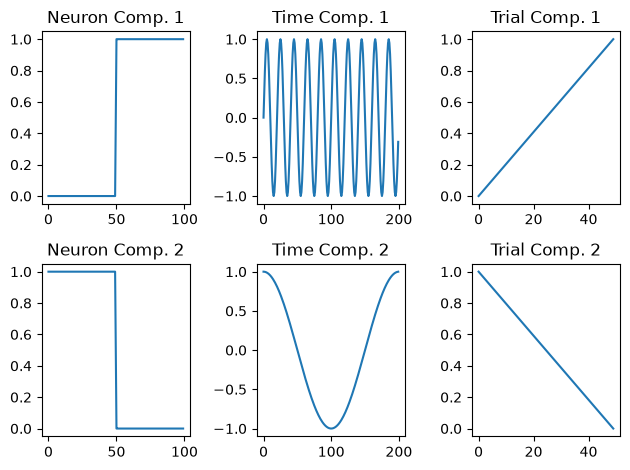

In [26]:
def sythentic_data(dims = (100, 200, 50), std = 0.1, ):
    """Function for generating synthetic data to run TCA on. Composed of two independent trial factors (a ramp and a sinusoid)
    that increase and decrease over trials, respectively.
    
    Inputs:
    dims: 3-dimensional tuple containing the dimensions of the returned neuron x time x trial tensor
    std: standard deviation of additive white noise
    Returns:
    a N x T x trial # """
    data = np.random.normal(scale = std, size = dims)


    return data

std = 1
dims = (100,200,50)
freq = 10
freq_2 = 1
data = np.random.normal(scale = std, size = dims)

#Vector elements of the first tensor component
vec_00 = np.concatenate((np.zeros(int(dims[0]/2)), np.ones(int(dims[0]/2))))
vec_01 = np.sin(2 * np.pi * freq * np.arange(0, dims[1]) / dims[1])
vec_02 = np.linspace(0,1,dims[2])
tensor_component_1 = np.einsum('i,j,k->ijk',vec_00, vec_01, vec_02) #computes the tensor outer product of the three vector components

#Vector elements of the second tensor component
vec_10 = vec_00[::-1]
vec_11 = np.cos(2 * np.pi * freq_2 * np.arange(0, dims[1]) / dims[1])
vec_12 = vec_02[::-1]
tensor_component_2 = np.einsum('i,j,k->ijk', vec_10, vec_11, vec_12) # computes the tensor outer product of the three vector components
fig, ax = plt.subplots(2, 3)
ax[0,0].plot(vec_00)
ax[0,0].set_title('Neuron Comp. 1')
ax[0,1].plot(vec_01)
ax[0,1].set_title('Time Comp. 1')
ax[0,2].plot(vec_02)
ax[0,2].set_title('Trial Comp. 1')

ax[1,0].plot(vec_10)
ax[1,0].set_title('Neuron Comp. 2')
ax[1,1].plot(vec_11)
ax[1,1].set_title('Time Comp. 2')
ax[1,2].plot(vec_12)
ax[1,2].set_title('Trial Comp. 2')
plt.tight_layout()

data += tensor_component_1
data += tensor_component_2


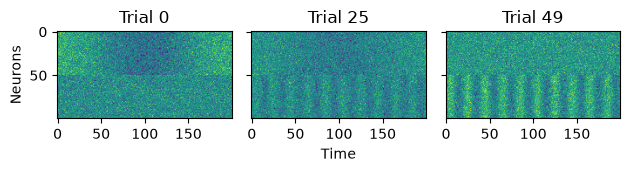

In [27]:
#Visualize the data

fig, ax = plt.subplots(1,3, sharey = True)

ax[0].imshow(data[:,:,0])
ax[0].set_title('Trial 0')
ax[0].set_ylabel('Neurons')

ax[1].imshow(data[:,:,int(dims[2]/2)])
ax[1].set_title(f'Trial {int(dims[2]/2)}')
ax[1].set_xlabel('Time')

ax[2].imshow(data[:,:, dims[2] - 1])
ax[2].set_title(f'Trial {dims[2] - 1}')
plt.tight_layout()

Rank-1 models:  min obj, 0.96;  max obj, 0.96;  time to fit, 0.1s


Rank-2 models:  min obj, 0.92;  max obj, 0.92;  time to fit, 0.0s


Rank-3 models:  min obj, 0.92;  max obj, 0.92;  time to fit, 0.0s


Rank-4 models:  min obj, 0.92;  max obj, 0.92;  time to fit, 0.0s


Rank-5 models:  min obj, 0.92;  max obj, 0.92;  time to fit, 0.0s


Rank-6 models:  min obj, 0.92;  max obj, 0.92;  time to fit, 0.1s


Rank-7 models:  min obj, 0.92;  max obj, 0.92;  time to fit, 0.1s


Rank-8 models:  min obj, 0.92;  max obj, 0.92;  time to fit, 0.1s


(<Figure size 800x200 with 6 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object),
 array([[list([<matplotlib.lines.Line2D object at 0x119c374d0>]),
         list([<matplotlib.lines.Line2D object at 0x119c55450>]),
         list([<matplotlib.lines.Line2D object at 0x119c57390>])],
        [list([<matplotlib.lines.Line2D object at 0x119c68b90>]),
         list([<matplotlib.lines.Line2D object at 0x119c68cd0>]),
         list([<matplotlib.lines.Line2D object at 0x119c68e10>])]],
       dtype=object))

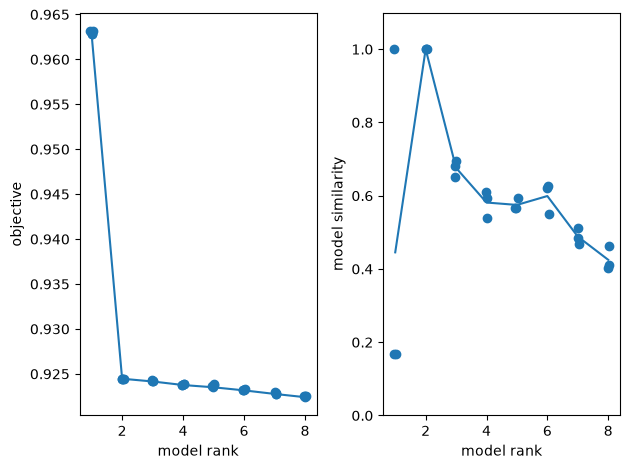

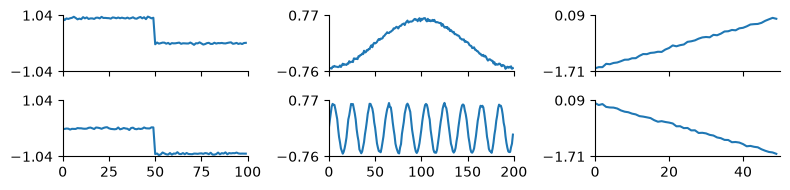

In [33]:
#Fit a tensor decomposition to the data and visualize the resulting factors

# Fit an ensemble of models, 4 random replicates / optimization runs per model rank
ensemble = tt.Ensemble(fit_method="cp_als")
ensemble.fit(data, ranks=range(1, 9), replicates=4)

fig, axes = plt.subplots(1, 2)
tt.plot_objective(ensemble, ax=axes[0])   # plot reconstruction error as a function of num components.
tt.plot_similarity(ensemble, ax=axes[1])  # plot model similarity as a function of num components.
fig.tight_layout()

# Plot the low-d factors for an example model, e.g. rank-2, first optimization run / replicate.
num_components = 2
replicate = 0
print(ensemble.factors(num_components)[replicate])
tt.plot_factors(ensemble.factors(num_components)[replicate])  # plot the low-d factors

# Outstanding Questions:
The tensor decomposition successfully uncovered the factors used to generate the data (ignoring sign flips). But this is a very simple dataset, designed to show off the power of TCA!

1. Can you design a dataset where TCA will __not__ recover the factors used to generate the data?

2. Can you design a dataset where TCA will require far more parameters to fit the data compared to an alternative tensor decomposition?

3. What happens if you do PCA on this synthetic dataset instead?

HINT: Answering these questions might require looking through some of the supplemental course materials linked above.

# Part 2: Fitting a tensor decomposition

In the previous section we used the tensortools codebase to compute our desired TCA factors. Here, we will work through the actual mechanics of using Alternating Least Squares (ALS) to compute the tensor components, by completing the function below and using it on our previous synthetic data.

# Problem setup

$\providecommand{\data}{\mathcal{D}}$

We want to approximate the data tensor $\data$ with a *simpler* tensor $\hat \data$ composed of components that are lower dimensional and easier to interpret. In analogy to low-rank matrix factorizations (e.g. PCA), we can suppose that the data matrix will be well-captured by $R$ sets of vectors, $\textbf{a}_r$, $\textbf{b}_r$, and $\textbf{c}_r$. Vectors $\textbf{a}$ are $N$-dimensional and dictate which neurons participate in the set, vectors $\textbf{b}_r$ are $T$-dimensional and dictate how the neurons' activity changes over time, and vecotrs $\textbf{c}_r$ are $K$-dimensional and dictate how the neurons' activity changes across trials.

We then approximate the data tensor as:

$
\hat \data = \sum_{r = 1}^R \textbf{a}_r \circ \textbf{b}_r \circ \textbf{c}_r,
$

Where $\cdot$ denotes the *tensor outer product*. For a particular tensor index $n,t,k$, this gives:

$
\hat \data_{n,t,k} = \sum_{r = 1}^R (a_n)_r (b_t)_r (c_k)_r.
$

We can organize our vectors into factor matrices:

$
\mathbf{A} = \begin{pmatrix} | & ... & | \\ \mathbf{a}_1 & ... & \mathbf{a}_R \\  | & ... & | \end{pmatrix} ~~~
\mathbf{B} = \begin{pmatrix} | & ... & | \\ \mathbf{b}_1 & ... & \mathbf{b}_R \\  | & ... & | \end{pmatrix} ~~~
\mathbf{C} = \begin{pmatrix} | & ... & | \\ \mathbf{c}_1 & ... & \mathbf{c}_R \\  | & ... & | \end{pmatrix}
$

And then we want to solve the minimization problem:

$
\argmin_{\mathbf{A},\mathbf{B},\mathbf{C}} \| \data - \hat \data \|_2^2 
$

$
= \argmin_{\mathbf{A},\mathbf{B},\mathbf{C}} \sum_{n,t,k} \left ( \data - \hat \data_{n,t,k} \right )^2 
$

$
=\argmin_{\mathbf{A},\mathbf{B},\mathbf{C}} \sum_{n,t,k} \left ( \data - \sum_{r=1}^R  \textbf{a}_r \circ \textbf{b}_r \circ \textbf{c}_r \right )^2.
$

This would be very difficult to optimize in $\mathbf{A}$, $\mathbf{B}$, and $\mathbf{C}$ simulataneously (the optimization is non-convex), but we can observe that the problem *is* convex in $\mathbf{A}$ is both $\mathbf{B}$ and $\mathbf{C}$ are held fixed. In fact, it is equivalent to a linear regression problem (see code for details)!

# Alternating Least Squares (ALS)

The alternating least squares algorithm performs this optimization by *coordinate descent*. First we optimize for $\mathbf{A}$, then we optimize for $\mathbf{B}$, then for $\mathbf{C}$, performing linear regression at each stage. This iteration scheme is then repeated until convergence. The TCA method additionally includes a normalization step to prevent degeneracy between the vectors $\mathbf{a}_r$, $\mathbf{b}_r$, and $\mathbf{c}_r$ (see code for details). In Pseudocode this gives us:


## Algorithm: Alternating Least Squares (ALS)

### INPUT: 
Tensor $\data$ and target rank $R$
### Output: 
$\mathbf{A}$, $\mathbf{B}$, $\mathbf{C}$ each with R columns used to fit D

Initialize $\mathbf{A},\mathbf{B},\mathbf{C}$ randomly

### Repeat until convergence:

$\mathbf{A} \leftarrow \argmin_a \| \data - \hat \data \|_2^2$

$\mathbf{B} \leftarrow \argmin_a \| \data - \hat \data \|_2^2$

$\mathbf{C} \leftarrow \argmin_a \| \data - \hat \data \|_2^2$

Renormalize($\mathbf{A}$,$\mathbf{B}$,$\mathbf{C}$)

Return $\mathbf{A}$,$\mathbf{B}$,$\mathbf{C}$

# Optimization mechanics

In the next section we will be filling in the steps that actually perform the optimization described above. To do this, we will rewrite each optimization explicitly as a linear regression problem, and use traditional linear regression optimizers to compute the optimal solution. This requires "reshaping" the data tensor into a matrix form. We use $\data_{(1)} \in \mathbb{R}^{n\times tk}$ to refer to the tensor "reshaped" such that its second and third mode are flattened into a single mode. Similarly, $\data_{(2)} \in \mathbb{R}^{t \times nk}$ and $\data_{(3)} \in \mathbb{R}^{k \times nt}$.

Similarly we define: $\mathrm{vec}\begin{pmatrix} | & ... & | \\ \mathbf{a}_1 & ... & \mathbf{a}_n \\ | & ... & | \end{pmatrix} = \begin{bmatrix} | \\ \mathbf{a}_1 \\ | \\ \vdots \\ | \\ \mathbf{a}_n \\ | \end{bmatrix}$.

To rewrite our optimization problem as a standard multivariate linear regression, we additionally need two *products*, one between vectors and one between matrices. For two vectors, we define the Kronecker product as:

\begin{equation}
\mathbf a_1 \otimes \mathbf a_2 = \mathrm{vec}(\mathbf a_2 \mathbf a_1^T),
\end{equation}

which takes the outer product of two vectors and flattens the resulting matrix.

Then, we define the *Khatri-Rao* product between two matrices, $\mathbf{A} \in \mathbb{R}^{m \times R}$ and $\mathbf{B} \in \mathbb{R}^{n \times R}$ as:

\begin{equation}
\mathbf{A} \odot \mathbf{B} = \begin{pmatrix} | & ... & | \\ \mathbf a_1 \otimes \mathbf b_2 & ... & \mathbf a_R \otimes \mathbf b_R \\ | & ... & | \\ \end{pmatrix}.
\end{equation}

This fills every column of the resultant matrix with the flattened outer product of the corresponding column vectors from $\mathbf A$ and $\mathbf B$.

Now we observe the following identities:

\begin{align}
\hat \data_{(1)} &= \mathbf A (\mathbf C \odot \mathbf B)^T \\
\hat \data_{(2)} &= \mathbf B (\mathbf C \odot \mathbf A)^T \\
\hat \data_{(3)} &= \mathbf C (\mathbf B \odot A)^T.
\end{align}

CHALLENGE: Prove these identities!

Then for each step of the alternating least squares problem, we can redefine the optimization as:

\begin{equation}
\mathbf{A} \leftarrow \argmin_\mathbf{A} \| \data - \hat \data \|_2^2 \equiv \argmin_{\mathbf{A}} \| \data_{(1)} - \mathbf A (\mathbf C \odot \mathbf B)^T \|_2^2.
\end{equation}

And similarly for $\mathbf{B}$,

\begin{equation}
\mathbf{B} \leftarrow \argmin_\mathbf{B} \| \data - \hat \data \|_2^2 \equiv \argmin_{\mathbf{B}} \| \data_{(2)} - \mathbf B (\mathbf C \odot \mathbf A)^T \|_2^2,
\end{equation}

and for $\mathbf{C}$,

\begin{equation}
\mathbf{C} \leftarrow \argmin_\mathbf{C} \| \data - \hat \data \|_2^2 \equiv \argmin_{\mathbf{C}} \| \data_{(3)} - \mathbf C (\mathbf B \odot \mathbf A)^T \|_2^2.
\end{equation}

These are multivariate linear regression problems, which can be solved using standard packages (e.g. ```scipy.linalg.cho_factor``` and ```scipy.linalg.cho_solve```).

## Final Note:

After fitting matrices $\mathbf A$, $\mathbf B$ and $\mathbf C$ for a given run of optimization, it is worth noting that a potential degeneracy exists between the fitted factors $\mathbf a_k$, $\mathbf b_k$, and $\mathbf c_k$: multiplying any one factor by a constant $d$ and dividing any other factor by the same constant $d$ will produce the same approximated data matrix $\hat \data$. This degeneracy can destabilize optimization, and is proof that the optimization procedure is *non-convex* (convex optimization problems always have unique optima).

In practice, one typically performs a ```rebalance(a,b,c)``` operation to normalize the "neuron" and "time" vectors to unit length, while allowing the "trial" vector to vary in magnitude. This is done at every step of the optimization.

## Coding Task:

In the segment below, complete the ```cp_als_rewrite``` function to implement the Alternating Least Squares algorithm. You can use the prewritten function ```khatri_rao(components)``` (imported from ```tensortools.operations```) to compute the Khatri-Rao product of factor matrices. 



In [ ]:
#Fill in the details of the cp_als function

import scipy.linalg

from tensortools.operations import unfold, khatri_rao
from tensortools.tensors import KTensor
from tensortools.optimize import FitResult, optim_utils

def cp_als_rewrite(X, rank, random_state=None, init='randn', skip_modes=[], **options):
    """Fits CP Decomposition using Alternating Least Squares (ALS).

    Parameters
    ----------
    X : (I_1, ..., I_N) array_like
        A tensor with ``X.ndim >= 3``.

    rank : integer
        The `rank` sets the number of components to be computed.

    random_state : integer, ``RandomState``, or ``None``, optional (default ``None``)
        If integer, sets the seed of the random number generator;
        If RandomState instance, random_state is the random number generator;
        If None, use the RandomState instance used by ``numpy.random``.

    init : str, or KTensor, optional (default ``'randn'``).
        Specifies initial guess for KTensor factor matrices.
        If ``'randn'``, Gaussian random numbers are used to initialize.
        If ``'rand'``, uniform random numbers are used to initialize.
        If KTensor instance, a copy is made to initialize the optimization.

    skip_modes : iterable, optional (default ``[]``).
        Specifies modes of the tensor that are not fit. This can be
        used to fix certain factor matrices that have been previously
        fit.

    options : dict, specifying fitting options.

        tol : float, optional (default ``tol=1E-5``)
            Stopping tolerance for reconstruction error.

        max_iter : integer, optional (default ``max_iter = 500``)
            Maximum number of iterations to perform before exiting.

        min_iter : integer, optional (default ``min_iter = 1``)
            Minimum number of iterations to perform before exiting.

        max_time : integer, optional (default ``max_time = np.inf``)
            Maximum computational time before exiting.

        verbose : bool ``{'True', 'False'}``, optional (default ``verbose=True``)
            Display progress.


    Returns
    -------
    result : FitResult instance
        Object which holds the fitted results. It provides the factor matrices
        in form of a KTensor, ``result.factors``.


    References
    ----------
    Kolda, T. G. & Bader, B. W.
    "Tensor Decompositions and Applications."
    SIAM Rev. 51 (2009): 455-500
    http://epubs.siam.org/doi/pdf/10.1137/07070111X

    Comon, Pierre & Xavier Luciani & Andre De Almeida.
    "Tensor decompositions, alternating least squares and other tales."
    Journal of chemometrics 23 (2009): 393-405.
    http://onlinelibrary.wiley.com/doi/10.1002/cem.1236/abstract

    
    Examples
    --------

    ```
    import tensortools as tt
    I, J, K, R = 20, 20, 20, 4
    X = tt.randn_tensor(I, J, K, rank=R)
    tt.cp_als(X, rank=R)
    ```
    """

    # Check inputs.
    optim_utils._check_cpd_inputs(X, rank)

    # Initialize problem.
    U, normX = optim_utils._get_initial_ktensor(init, X, rank, random_state)
    result = FitResult(U, 'CP_ALS', **options)

    # Main optimization loop.
    while result.still_optimizing:

        # Iterate over each tensor mode.
        for n in range(X.ndim):

            # Skip modes that are specified as fixed.
            if n in skip_modes:
                continue

            # i) Normalize factors to prevent singularities.
            U.rebalance()

            # ii) Compute the N-1 gram matrices.
            components = [U[j] for j in range(X.ndim) if j != n]
            grams = np.prod([u.T @ u for u in components], axis=0)

            # iii)  Compute Khatri-Rao product.
            # [INSERT CODE HERE]

            # iv) Form normal equations and solve via Cholesky
            
            # U[n] = [INSERT CODE HERE]

        # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        # Update the optimization result, checks for convergence.
        # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        # Compute objective function
        # grams *= U[-1].T.dot(U[-1])
        # obj = np.sqrt(np.sum(grams) - 2*np.sum(p*U[-1]) + normX**2) / normX
        obj = np.linalg.norm(U.full() - X) / normX

        # Update result
        result.update(obj)

    # Finalize and return the optimization result.
    return result.finalize()

CP_ALS: iteration 1, objective 0.998086837682263, improvement inf.
CP_ALS: iteration 2, objective 0.968597395016656, improvement 0.029489442665607046.
CP_ALS: iteration 3, objective 0.951208284703315, improvement 0.017389110313341005.
CP_ALS: iteration 4, objective 0.9454141785981282, improvement 0.005794106105186825.
CP_ALS: iteration 5, objective 0.9445507111029304, improvement 0.0008634674951977228.
CP_ALS: iteration 6, objective 0.9442658048039667, improvement 0.00028490629896371633.
CP_ALS: iteration 7, objective 0.9433864788087908, improvement 0.000879325995175928.
CP_ALS: iteration 8, objective 0.940072821128052, improvement 0.0033136576807387685.
CP_ALS: iteration 9, objective 0.9329183413885171, improvement 0.007154479739534869.
CP_ALS: iteration 10, objective 0.9271941635972657, improvement 0.00572417779125145.
CP_ALS: iteration 11, objective 0.9250054818646454, improvement 0.0021886817326203234.
CP_ALS: iteration 12, objective 0.9245151884957017, improvement 0.00049029336894

(<Figure size 800x200 with 6 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object),
 array([[list([<matplotlib.lines.Line2D object at 0x119e939d0>]),
         list([<matplotlib.lines.Line2D object at 0x119ecd950>]),
         list([<matplotlib.lines.Line2D object at 0x119ecf890>])],
        [list([<matplotlib.lines.Line2D object at 0x119eed090>]),
         list([<matplotlib.lines.Line2D object at 0x119eed1d0>]),
         list([<matplotlib.lines.Line2D object at 0x119eed310>])]],
       dtype=object))

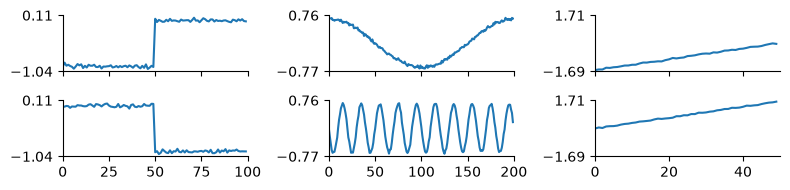

In [37]:
#Test cp_als on synthetic data

rank = 2
result = cp_als_rewrite(data, rank = rank)
tt.plot_factors(result.factors)  # plot the low-d factors


# Part 3: Applying TCA to neural data

In this section you will be applying TCA to the dataset that I discussed in my talk. See what cool results you can find! This section is intended to be open-ended. Feel free to play around however you would like, and to incorporate any additional methods that you find interesting. If you would prefer to play with your own data, that's great too!

First, we will preprocess the data to put it into a format that will be useful for our analyses, by aligning it to important timepoints within each trial


In [ ]:
#load the data
path = "M1_LC_data.npy"
data_dict = np.load(path, allow_pickle = True)
if type(data_dict) is np.ndarray:
    data_dict = data_dict.item()

data_dict_axon = data_dict['ch1']

#data_dict_axon contains a dictionary with data generated from Locus Coeruleus axons projecting to motor cortex
axon_F = data_dict_axon['F']

#data_dict contains a dictionary with data recorded from motor cortex (M1) simultaneously with the data taken from LC axons
cell_F = data_dict['F']

# Time x Neuron x Trial Tensors
print(axon_F.shape) 
print(cell_F.shape)

(240, 55, 306)
(240, 220, 306)


In [ ]:
def extract_event_driven_activity(data, event_times, window_left = -20, window_right = 20):
    """Helper function to extract neuronal data around particular events within a trial
    INPUT: data is a Time x Neuron x Trial tensor
           event_times is a event # matrix
    RETURNS: a (window_right - window_left + 1) x neuron x event # tensor
    """
    
    event_num = len(event_times)
    data_mat = np.zeros((window_right - window_left + 1, data.shape[1], event_num))
    for idx in range(0, len(event_times)):
        if np.isnan(event_times[idx]):
            data_mat[:,:,idx] = np.nan
        else:
            if data[(int(event_times[idx]) + window_left):(int(event_times[idx])+window_right + 1), :, idx].shape[0] != (window_right - window_left + 1):
                data_mat[:,:,idx] = np.nan
            else:
                data_mat[:,:,idx] = data[(int(event_times[idx]) + window_left):(int(event_times[idx])+window_right + 1), :, idx]

    return data_mat


reward_array = []
dt = data_dict['dt_si'] #amount of time (ms) for each time step in the tensor
reward_times = data_dict['reward_time']
trial_start_idx = np.where(np.logical_not(np.isnan(axon_F[:,0,0])))[0][0] #data_dict['trial_start']

#extract reward times from the data
for idx, time in enumerate(reward_times):
    if len(reward_times[idx]) == 1:
        reward_array.append(int(trial_start_idx + int(reward_times[idx].item() / dt)))
    elif len(reward_times[idx]) == 0:
        reward_array.append(np.nan)

reward_array = np.hstack(reward_array)

#extract axon activity around rewards (40 timesteps prior to 60 timesteps after)
window = [-40, 40]
reward_responses_axon = extract_event_driven_activity(axon_F, reward_array, window_left = window[0], window_right = window[1])

#extract cell activity around rewards
window = [-40, 40]
reward_responses_cell = extract_event_driven_activity(cell_F, reward_array, window_left = window[0], window_right = window[1])

# extract axon activity around trial start (40 timesteps prior to 60 timesteps after)
trial_start_axon = np.ones(axon_F.shape[2]) * trial_start_idx #40
window = [-40, 60]
trial_start_responses_axon = extract_event_driven_activity(axon_F, trial_start_axon, window_left = window[0], window_right = window[1])

# extract axon activity around trial start
trial_start_cell = np.ones(cell_F.shape[2]) * trial_start_idx #40
window = [-40, 60]
trial_start_responses_cell = extract_event_driven_activity(cell_F, trial_start_cell, window_left = window[0], window_right = window[1])

print(reward_responses_axon.shape)
print(trial_start_responses_axon.shape)

print(reward_responses_cell.shape)
print(trial_start_responses_cell.shape)

(81, 55, 306)
(101, 55, 306)
(81, 220, 306)
(101, 220, 306)


## Exercise:

You now have 4 separate tensors: 1) axon responses aligned to reward, 2) axon responses aligned to trial start, 3) cell responses aligned to reward, 4) cell responses aligned to trial start.

Perform TCA on these different tensors, and see if you can discover any interesting relationships. HINT: Start with 1 component; trial start-aligned responses will be easier to manage!